In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("Imports OK")
print(f"Pandas : {pd.__version__}")
print(f"NumPy  : {np.__version__}")

Imports OK
Pandas : 2.3.3
NumPy  : 2.2.6


In [2]:
random.seed(42)
np.random.seed(42)

def generate_patient(patient_id: int) -> dict:
    """Génère un patient fictif avec profil clinique réaliste."""
    age = random.randint(35, 85)
    has_hta = random.random() > 0.5
    has_diabetes = random.random() > 0.6
    has_cardiac = random.random() > 0.7

    # La tension de base dépend des comorbidités
    base_systolic = 120 + (20 if has_hta else 0) + (age - 50) * 0.3
    base_glucose = 5.5 + (3.0 if has_diabetes else 0) + np.random.normal(0, 0.5)

    return {
        "patient_id": f"P{patient_id:04d}",
        "age": age,
        "gender": random.choice(["M", "F"]),
        "has_hta": has_hta,
        "has_diabetes": has_diabetes,
        "has_cardiac": has_cardiac,
        "base_systolic": round(base_systolic, 1),
        "base_glucose": round(base_glucose, 2),
        "n_comorbidities": sum([has_hta, has_diabetes, has_cardiac])
    }

# Génération de 200 patients
patients = [generate_patient(i) for i in range(1, 201)]
df_patients = pd.DataFrame(patients)

print(f" {len(df_patients)} patients générés")
df_patients.head(10)

 200 patients générés


,patient_id,age,gender,has_hta,has_diabetes,has_cardiac,base_systolic,base_glucose,n_comorbidities
0,P0001,75,M,False,True,False,127.5,8.75,1
1,P0002,82,F,False,True,False,129.6,8.43,1
2,P0003,37,M,False,False,False,116.1,5.82,0
3,P0004,70,M,False,True,False,126.0,9.26,1
4,P0005,63,M,True,True,False,143.9,8.38,2
5,P0006,79,F,False,False,False,128.7,5.38,0
6,P0007,41,F,False,False,True,117.3,6.29,1
7,P0008,37,F,True,False,True,136.1,5.88,2
8,P0009,40,F,True,True,False,137.0,8.27,2
9,P0010,71,F,False,False,False,126.3,5.77,0


In [3]:
def generate_vitals_history(patient: dict, n_days: int = 90) -> pd.DataFrame:
    """
    Génère 90 jours de mesures de constantes pour un patient.
    Intègre des tendances réalistes selon les comorbidités.
    """
    records = []
    base_date = datetime(2024, 1, 1)

    for day in range(n_days):
        # Tendance de dégradation légère si comorbidités multiples
        degradation = day * 0.05 * patient["n_comorbidities"]

        record = {
            "patient_id": patient["patient_id"],
            "date": (base_date + timedelta(days=day)).strftime("%Y-%m-%d"),
            "day": day,
            "systolic_bp": round(
                patient["base_systolic"] + degradation + np.random.normal(0, 8), 1
            ),
            "diastolic_bp": round(
                (patient["base_systolic"] * 0.65) + np.random.normal(0, 5), 1
            ),
            "heart_rate": round(
                72 + (10 if patient["has_cardiac"] else 0) + np.random.normal(0, 6), 1
            ),
            "glucose": round(
                patient["base_glucose"] + np.random.normal(0, 0.8), 2
            ),
            "weight": round(
                70 + patient["age"] * 0.1 + np.random.normal(0, 1.5), 1
            ),
            "temperature": round(np.random.normal(37.0, 0.3), 1),
        }
        records.append(record)

    return pd.DataFrame(records)

# Génération pour les 20 premiers patients
all_vitals = pd.concat([
    generate_vitals_history(p) for p in patients[:20]
], ignore_index=True)

print(f" {len(all_vitals)} mesures générées pour 20 patients")
print(f"Période : {all_vitals['date'].min()} → {all_vitals['date'].max()}")
all_vitals.head()

 1800 mesures générées pour 20 patients
Période : 2024-01-01 → 2024-03-30


,patient_id,date,day,systolic_bp,diastolic_bp,heart_rate,glucose,weight,temperature
0,P0001,2024-01-01,0,130.4,85.7,78.5,9.59,75.4,36.7
1,P0001,2024-01-02,1,131.7,85.4,75.1,11.83,78.4,37.3
2,P0001,2024-01-03,2,135.2,86.1,70.1,9.36,76.3,36.9
3,P0001,2024-01-04,3,123.8,83.3,85.9,7.26,78.5,36.5
4,P0001,2024-01-05,4,123.9,88.3,72.4,7.89,76.4,37.2


In [5]:
CONSULTATION_TEMPLATES = {
    "cardio": [
        "Patient se plaint de douleurs thoraciques depuis {n} jours. Légère dyspnée à l'effort. Pas de syncope.",
        "Consultation pour palpitations récurrentes. Tachycardie à {hr} bpm. Antécédents d'HTA.",
        "Oedème des membres inférieurs bilatéral. Essoufflement au moindre effort. Bilan cardiaque requis.",
    ],
    "metabolic": [
        "Contrôle diabète type 2. Glycémie à jeun à {gl} mmol/L. Observance traitement correcte.",
        "Patient en surpoids, IMC à {imc}. Fatigue chronique, soif excessive. Suspicion diabète.",
        "Bilan lipidique perturbé. Cholestérol total élevé. Adapter le régime alimentaire.",
    ],
    "infectious": [
        "Fièvre à {temp}°C depuis {n} jours. Toux productive. Auscultation : râles à droite.",
        "Infection urinaire suspectée. Brûlures mictionnelles. ECBU prescrit.",
        "Syndrome grippal. Fièvre, myalgies, asthénie marquée. Test antigénique négatif.",
    ],
    "normal": [
        "Consultation de routine. Pas de plainte particulière. Constantes normales.",
        "Renouvellement d'ordonnance. Patient asymptomatique. Bonne tolérance traitement.",
        "Bilan annuel. Examen clinique sans particularité. Vaccination mise à jour.",
    ]
}

def generate_consultation_note(patient: dict) -> dict:
    """Génère une note de consultation réaliste selon le profil patient."""
    if patient["has_cardiac"] and random.random() > 0.4:
        category = "cardio"
    elif patient["has_diabetes"] and random.random() > 0.4:
        category = "metabolic"
    elif random.random() > 0.7:
        category = "infectious"
    else:
        category = "normal"

    template = random.choice(CONSULTATION_TEMPLATES[category])
    note = template.format(
        n=random.randint(2, 14),
        hr=random.randint(95, 130),
        gl=round(patient["base_glucose"] + random.uniform(-1, 3), 1),
        imc=round(25 + random.uniform(0, 15), 1),
        temp=round(37.5 + random.uniform(0, 2), 1)
    )

    return {
        "patient_id": patient["patient_id"],
        "note": note,
        "category": category,
        "label": 1 if category != "normal" else 0
    }

# Génération de 500 notes
notes = [generate_consultation_note(random.choice(patients)) for _ in range(500)]
df_notes = pd.DataFrame(notes)

print(f" {len(df_notes)} notes générées")
print("\nDistribution des catégories :")
print(df_notes["category"].value_counts())

 500 notes générées

Distribution des catégories :
category
normal        217
metabolic     119
infectious     99
cardio         65
Name: count, dtype: int64


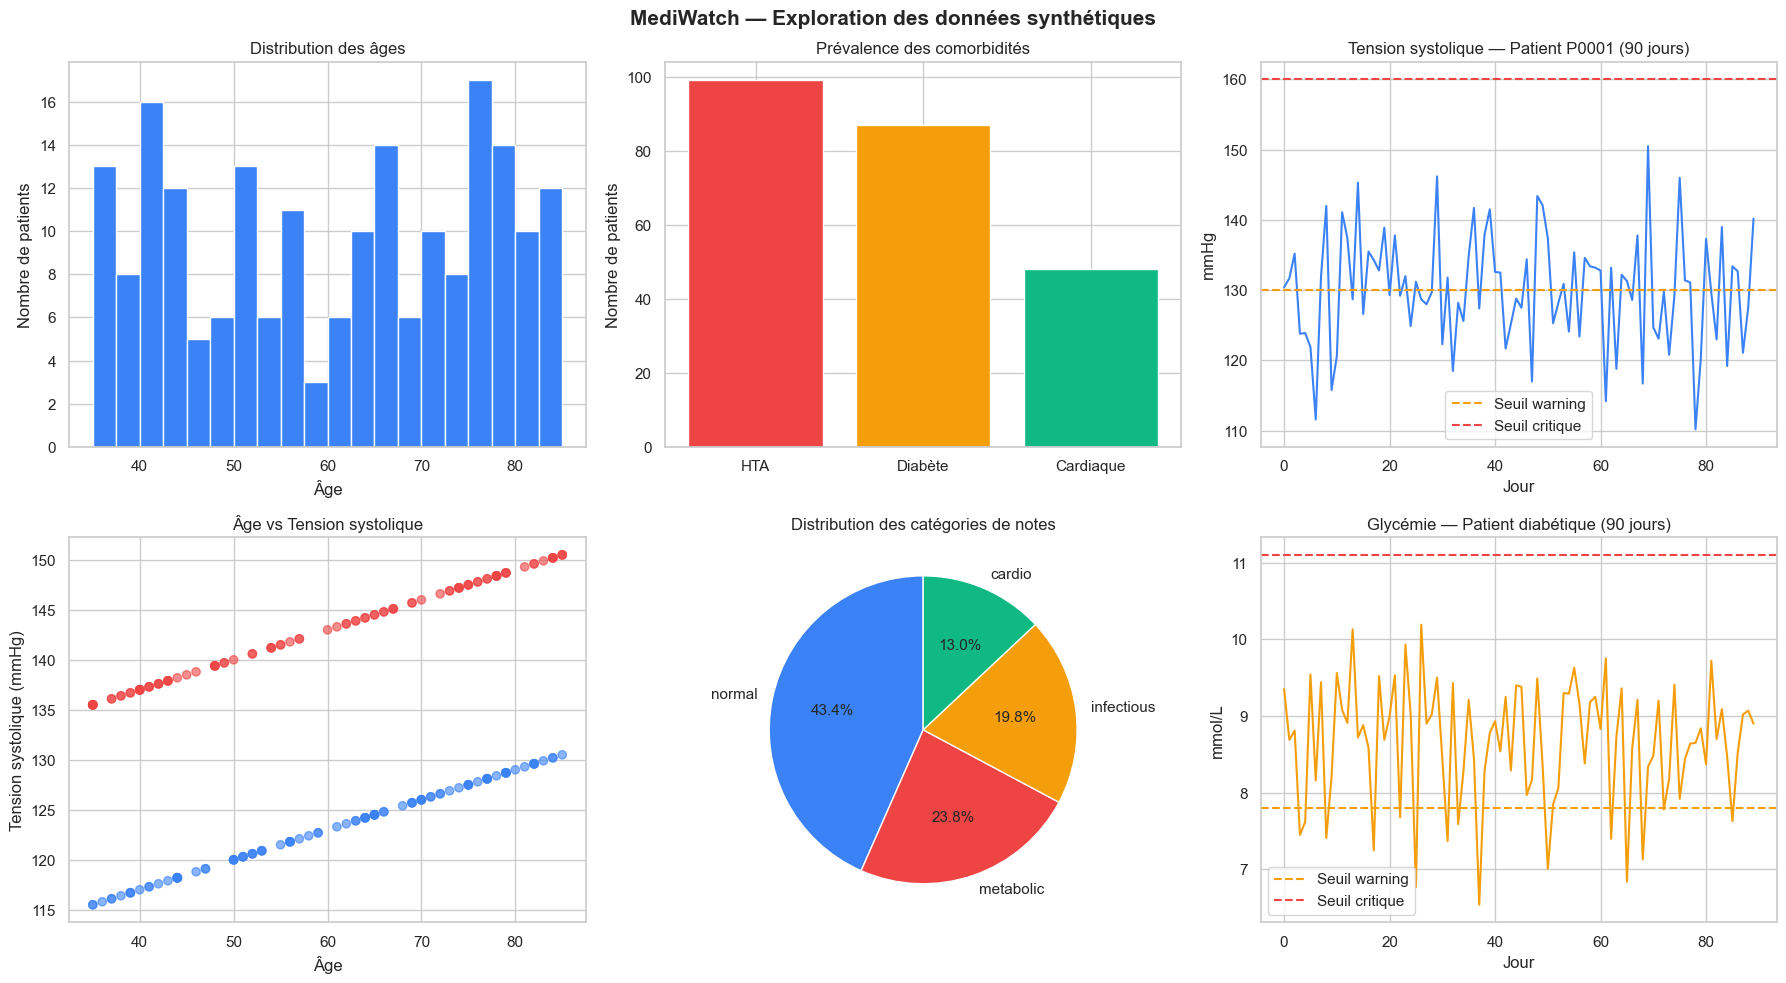

Dashboard sauvegardé dans data/processed/


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("MediWatch — Exploration des données synthétiques", fontsize=15, fontweight='bold')

# 1. Distribution des âges
axes[0, 0].hist(df_patients["age"], bins=20, color="#3b82f6", edgecolor="white")
axes[0, 0].set_title("Distribution des âges")
axes[0, 0].set_xlabel("Âge")
axes[0, 0].set_ylabel("Nombre de patients")

# 2. Prévalence des comorbidités
comorbidities = {
    "HTA": df_patients["has_hta"].sum(),
    "Diabète": df_patients["has_diabetes"].sum(),
    "Cardiaque": df_patients["has_cardiac"].sum()
}
axes[0, 1].bar(comorbidities.keys(), comorbidities.values(),
               color=["#ef4444", "#f59e0b", "#10b981"])
axes[0, 1].set_title("Prévalence des comorbidités")
axes[0, 1].set_ylabel("Nombre de patients")

# 3. Distribution tension systolique
patient_vitals = all_vitals[all_vitals["patient_id"] == "P0001"]
axes[0, 2].plot(patient_vitals["day"], patient_vitals["systolic_bp"],
                color="#3b82f6", linewidth=1.5)
axes[0, 2].axhline(y=130, color="#f59e0b", linestyle="--", label="Seuil warning")
axes[0, 2].axhline(y=160, color="#ef4444", linestyle="--", label="Seuil critique")
axes[0, 2].set_title("Tension systolique — Patient P0001 (90 jours)")
axes[0, 2].set_xlabel("Jour")
axes[0, 2].set_ylabel("mmHg")
axes[0, 2].legend()

# 4. Corrélation âge / tension
axes[1, 0].scatter(df_patients["age"], df_patients["base_systolic"],
                   c=df_patients["has_hta"].map({True: "#ef4444", False: "#3b82f6"}),
                   alpha=0.6)
axes[1, 0].set_title("Âge vs Tension systolique")
axes[1, 0].set_xlabel("Âge")
axes[1, 0].set_ylabel("Tension systolique (mmHg)")

# 5. Distribution des catégories de notes
category_counts = df_notes["category"].value_counts()
colors = ["#3b82f6", "#ef4444", "#f59e0b", "#10b981"]
axes[1, 1].pie(category_counts.values, labels=category_counts.index,
               colors=colors, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title("Distribution des catégories de notes")

# 6. Évolution glycémie patient diabétique
diabetic = df_patients[df_patients["has_diabetes"]].iloc[0]
vitals_diab = generate_vitals_history(diabetic.to_dict())
axes[1, 2].plot(vitals_diab["day"], vitals_diab["glucose"],
                color="#f59e0b", linewidth=1.5)
axes[1, 2].axhline(y=7.8, color="#f59e0b", linestyle="--", label="Seuil warning")
axes[1, 2].axhline(y=11.1, color="#ef4444", linestyle="--", label="Seuil critique")
axes[1, 2].set_title("Glycémie — Patient diabétique (90 jours)")
axes[1, 2].set_xlabel("Jour")
axes[1, 2].set_ylabel("mmol/L")
axes[1, 2].legend()

plt.tight_layout()
plt.savefig("../data/processed/exploration_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard sauvegardé dans data/processed/")

In [7]:
import os

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../data/synthetic", exist_ok=True)

# Sauvegarde CSV
df_patients.to_csv("../data/synthetic/patients.csv", index=False)
all_vitals.to_csv("../data/synthetic/vitals_history.csv", index=False)
df_notes.to_csv("../data/synthetic/consultation_notes.csv", index=False)

print("Données sauvegardées :")
print(f"  → data/synthetic/patients.csv          ({len(df_patients)} lignes)")
print(f"  → data/synthetic/vitals_history.csv    ({len(all_vitals)} lignes)")
print(f"  → data/synthetic/consultation_notes.csv ({len(df_notes)} lignes)")

Données sauvegardées :
  → data/synthetic/patients.csv          (200 lignes)
  → data/synthetic/vitals_history.csv    (1800 lignes)
  → data/synthetic/consultation_notes.csv (500 lignes)
